Размер датасета: (99, 4)

Распределение классов:
 status
1.0    49
0.0    49
Name: count, dtype: int64

Процент мошеннических объявлений: 50.00%

Пропуски:
 label        0
text         0
status       1
full_text    0
dtype: int64


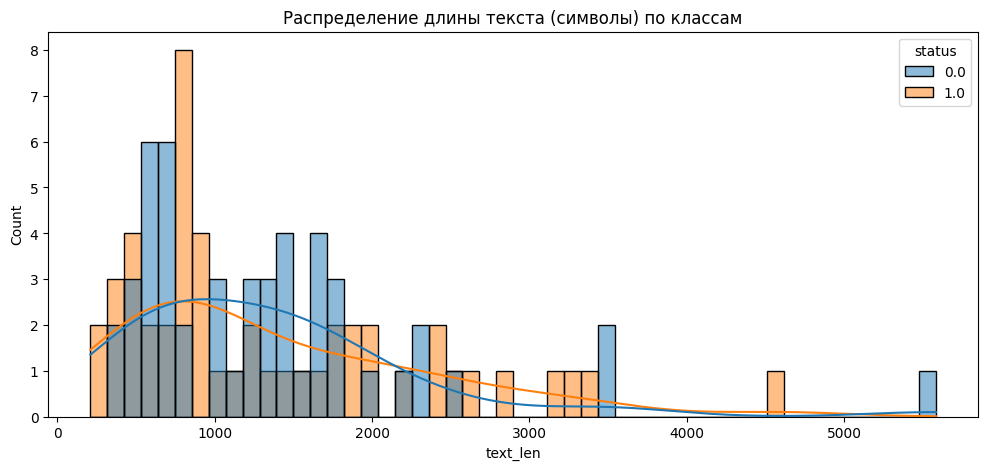

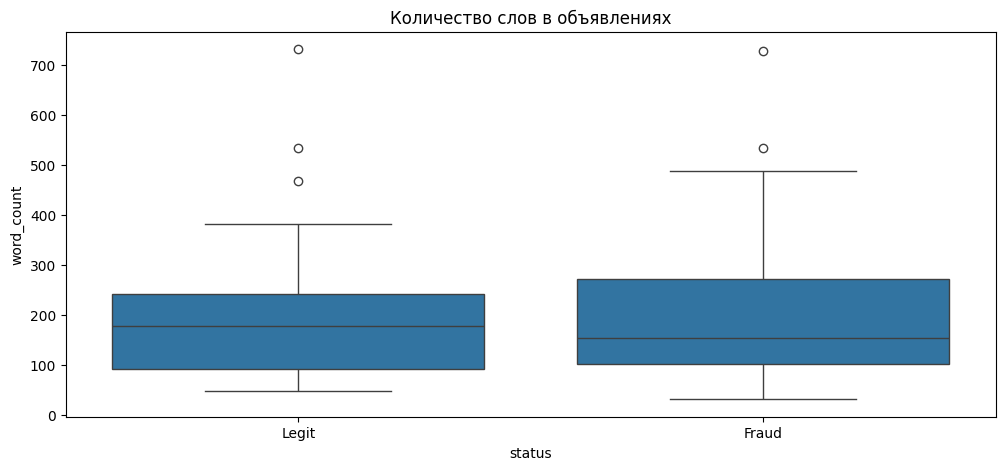

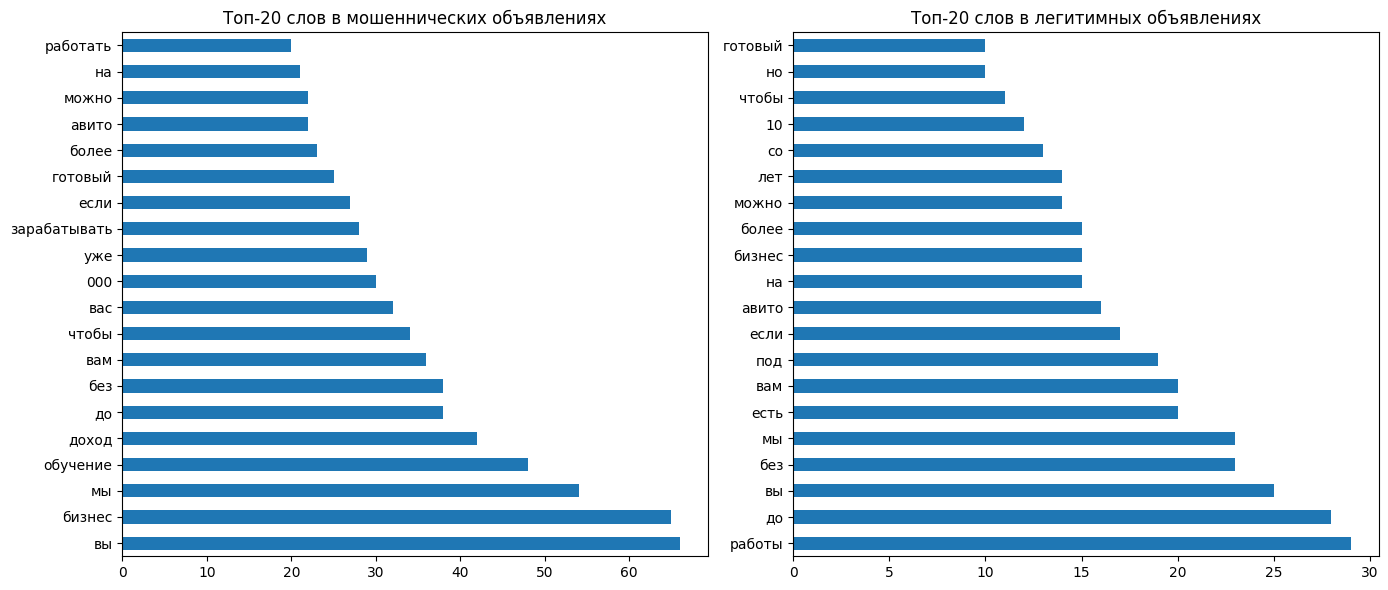

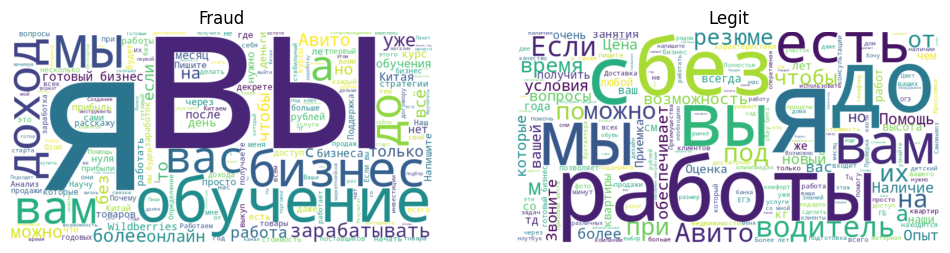

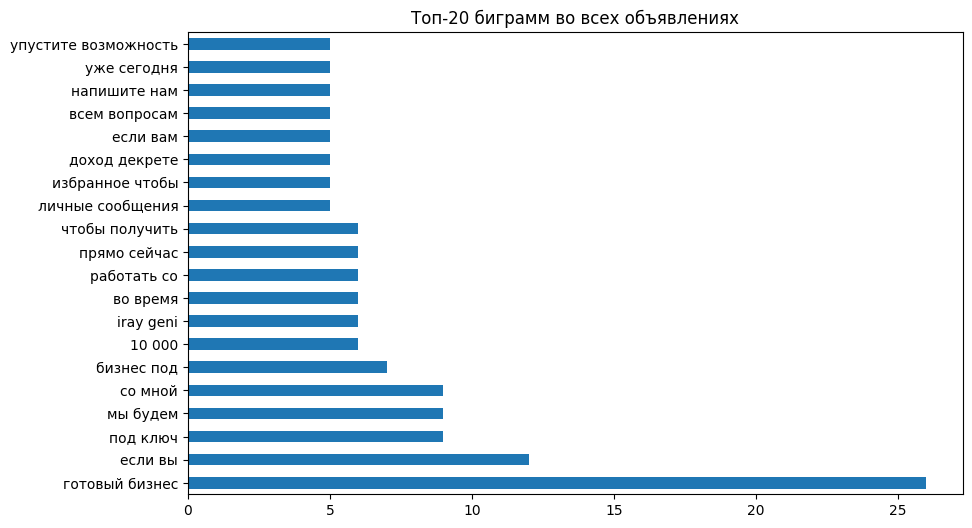

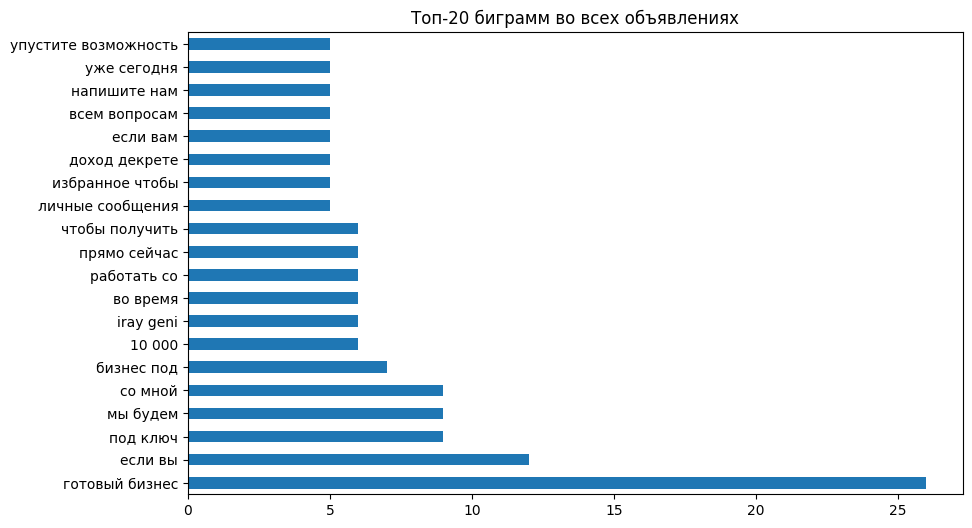

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
from sklearn.feature_extraction.text import CountVectorizer

# 1. Загрузка данных
df = pd.read_csv("/content/sample_data/ready_clean.txt", sep=',', encoding='utf-8')

# 2. Преобразование меток
df['status'] = df['status'].map({'legit': 0, 'fraud': 1})

# 3. Создание полного текста
df['full_text'] = df['label'].fillna('') + " " + df['text'].fillna('')

# 4. Базовые характеристики
print("Размер датасета:", df.shape)
print("\nРаспределение классов:\n", df['status'].value_counts())
print("\nПроцент мошеннических объявлений: {:.2f}%".format(df['status'].mean()*100))
print("\nПропуски:\n", df.isnull().sum())

# 5. Длина текста и количество слов
df['text_len'] = df['full_text'].apply(len)
df['word_count'] = df['full_text'].apply(lambda x: len(x.split()))

plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='text_len', hue='status', bins=50, kde=True)
plt.title('Распределение длины текста (символы) по классам')
plt.show()

plt.figure(figsize=(12, 5))
sns.boxplot(data=df, x='status', y='word_count')
plt.title('Количество слов в объявлениях')
plt.xticks([0,1], ['Legit', 'Fraud'])
plt.show()

# 6. Топ-слов для каждого класса
stop_words = ['и', 'в', 'на', 'с', 'по', 'от', 'для', 'за', 'о', 'у', 'к', 'из', 'не', 'что', 'как', 'это', 'все', 'так', 'или']

vectorizer = CountVectorizer(stop_words=stop_words, max_features=30)
X_counts = vectorizer.fit_transform(df['full_text'])
words = vectorizer.get_feature_names_out()

# Разделение по классам
fraud_mask = df['status'] == 1
legit_mask = df['status'] == 0

# Преобразуем маски в numpy массивы для индексации разреженной матрицы
fraud_counts = X_counts[fraud_mask.values].toarray().sum(axis=0)
legit_counts = X_counts[legit_mask.values].toarray().sum(axis=0)

fraud_top = pd.Series(fraud_counts, index=words).sort_values(ascending=False).head(20)
legit_top = pd.Series(legit_counts, index=words).sort_values(ascending=False).head(20)

fig, axes = plt.subplots(1,2, figsize=(14,6))
fraud_top.plot(kind='barh', ax=axes[0], title='Топ-20 слов в мошеннических объявлениях')
legit_top.plot(kind='barh', ax=axes[1], title='Топ-20 слов в легитимных объявлениях')
plt.tight_layout()
plt.show()

# 7. Облака слов
fraud_text = ' '.join(df[df['status']==1]['full_text'])
legit_text = ' '.join(df[df['status']==0]['full_text'])

wordcloud_fraud = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(fraud_text)
wordcloud_legit = WordCloud(width=800, height=400, background_color='white', stopwords=stop_words).generate(legit_text)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(wordcloud_fraud, interpolation='bilinear')
plt.title('Fraud')
plt.axis('off')
plt.subplot(1,2,2)
plt.imshow(wordcloud_legit, interpolation='bilinear')
plt.title('Legit')
plt.axis('off')
plt.show()

# 8. Биграммы
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words=stop_words, max_features=20)
bigrams = bigram_vectorizer.fit_transform(df['full_text'])
bigram_words = bigram_vectorizer.get_feature_names_out()
bigram_counts = bigrams.toarray().sum(axis=0)
bigram_freq = pd.Series(bigram_counts, index=bigram_words).sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
bigram_freq.plot(kind='barh')
plt.title('Топ-20 биграмм во всех объявлениях')
plt.show()

# 9. Интерактивные графики Plotly
fig = px.histogram(df, x='word_count', color='status', nbins=50,
                   title='Распределение количества слов')
fig.show()

fig = px.scatter(df, x='text_len', y='word_count', color='status',
                 title='Зависимость длины текста от количества слов')
fig.show()

# 8. Биграммы
bigram_vectorizer = CountVectorizer(ngram_range=(2,2), stop_words=stop_words, max_features=20)
bigrams = bigram_vectorizer.fit_transform(df['full_text'])
bigram_words = bigram_vectorizer.get_feature_names_out()
bigram_counts = bigrams.toarray().sum(axis=0)
bigram_freq = pd.Series(bigram_counts, index=bigram_words).sort_values(ascending=False).head(20)

plt.figure(figsize=(10,6))
bigram_freq.plot(kind='barh')
plt.title('Топ-20 биграмм во всех объявлениях')
plt.show()

# 9. Интерактивные графики Plotly
fig = px.histogram(df, x='word_count', color='status', nbins=50,
                   title='Распределение количества слов')
fig.show()

fig = px.scatter(df, x='text_len', y='word_count', color='status',
                 title='Зависимость длины текста от количества слов')
fig.show()

In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score)
from sklearn.dummy import DummyClassifier

# Фиксируем random_state для воспроизводимости
RANDOM_STATE = 42

# Загрузка
df = pd.read_csv("/content/sample_data/ready_clean.txt", sep=',', encoding='utf-8')

# Преобразование меток: legit -> 0, fraud -> 1
df["status"] = df["status"].map({"legit": 0, "fraud": 1})
df.dropna(subset=["status"], inplace=True)

# Объединяем заголовок и текст в один признак
df["full_text"] = df["label"].fillna('') + " " + df["text"].fillna('')

X = df["full_text"]
y = df["status"]

# Стратифицированное разбиение для сохранения пропорции классов
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f"Размер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")
print(f"Доля мошенничества в обучающей: {y_train.mean():.3f}")
print(f"Доля мошенничества в тестовой: {y_test.mean():.3f}")

# Создаём dummy-классификатор, который всегда предсказывает самый частый класс
dummy = DummyClassifier(strategy="most_frequent", random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)

# Предсказания на тестовой выборке
y_pred_dummy = dummy.predict(X_test)

# Метрики
dummy_metrics = {
    'accuracy': accuracy_score(y_test, y_pred_dummy),
    'precision': precision_score(y_test, y_pred_dummy, pos_label=1),
    'recall': recall_score(y_test, y_pred_dummy, pos_label=1),
    'f1': f1_score(y_test, y_pred_dummy, pos_label=1)
}

print("Константный baseline (most_frequent):")
for metric, value in dummy_metrics.items():
    print(f"  {metric.capitalize()}: {value:.4f}")

    # Пайплайн: TF-IDF → LinearSVC
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=5000, ngram_range=(1, 2))),
    ('clf', LinearSVC(class_weight='balanced', random_state=RANDOM_STATE))
])

# Сетка гиперпараметров
param_grid = {
    'tfidf__max_features': [1000, 5000],
    'tfidf__ngram_range': [(1,1), (1,2)],
    'clf__C': [0.1, 1, 10]
}

# GridSearch с оптимизацией по F1-score (основная метрика)
grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='f1',                 # используем стандартный scorer
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=1
)

# Обучение на тренировочной выборке
grid.fit(X_train, y_train)

print("Лучшие параметры:", grid.best_params_)
print(f"Лучшее F1 на кросс-валидации: {grid.best_score_:.4f}")

# Лучшая модель
best_model = grid.best_estimator_

# Предсказания на тестовой выборке
y_pred = best_model.predict(X_test)

# Метрики
test_metrics = {
    'accuracy': accuracy_score(y_test, y_pred),
    'precision': precision_score(y_test, y_pred, pos_label=1),
    'recall': recall_score(y_test, y_pred, pos_label=1),
    'f1': f1_score(y_test, y_pred, pos_label=1)
}

print("\nМетрики на тестовой выборке (LinearSVC + TF‑IDF):")
for metric, value in test_metrics.items():
    print(f"  {metric.capitalize()}: {value:.4f}")

    print("\nСравнение с константным baseline:")
for metric in ['f1', 'precision', 'recall', 'accuracy']:
    baseline_val = dummy_metrics[metric]
    model_val = test_metrics[metric]
    print(f"  {metric.capitalize()}: baseline={baseline_val:.4f}, model={model_val:.4f} -> improvement={model_val - baseline_val:.4f}")

Размер обучающей выборки: 78
Размер тестовой выборки: 20
Доля мошенничества в обучающей: 0.500
Доля мошенничества в тестовой: 0.500
Константный baseline (most_frequent):
  Accuracy: 0.5000
  Precision: 0.0000
  Recall: 0.0000
  F1: 0.0000
Fitting 5 folds for each of 12 candidates, totalling 60 fits


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning:

Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.



Лучшие параметры: {'clf__C': 0.1, 'tfidf__max_features': 5000, 'tfidf__ngram_range': (1, 2)}
Лучшее F1 на кросс-валидации: 0.9765

Метрики на тестовой выборке (LinearSVC + TF‑IDF):
  Accuracy: 0.9000

Сравнение с константным baseline:
  Precision: 0.8333

Сравнение с константным baseline:
  Recall: 1.0000

Сравнение с константным baseline:
  F1: 0.9091

Сравнение с константным baseline:
  F1: baseline=0.0000, model=0.9091 -> improvement=0.9091
  Precision: baseline=0.0000, model=0.8333 -> improvement=0.8333
  Recall: baseline=0.0000, model=1.0000 -> improvement=1.0000
  Accuracy: baseline=0.5000, model=0.9000 -> improvement=0.4000
